# Evaluación Parcial N°1: Clasificación de Lenguaje de Señas (ASL) mediante MLP

## FASE 1: Comprensión del Negocio (Business Understanding)

* **Problema de Negocio:** Las personas con discapacidad auditiva enfrentan barreras de comunicación significativas. Se requiere desarrollar un sistema de visión computacional accesible que permita traducir gestos del alfabeto de la lengua de señas a texto en tiempo real, facilitando la inclusión.
* **Objetivo del Proyecto:** Implementar, entrenar y evaluar una Red Neuronal Densa (MLP) capaz de clasificar imágenes de 28x28 píxeles en 24 clases del Alfabeto de Lengua de Señas Americano (excluyendo J y Z).
* **Justificación del Dataset:** Se utiliza "Sign Language MNIST". Aunque la rúbrica asocia por error el lenguaje de señas al dataset "Los Simpson", este es el dataset oficial MNIST para señas.
* **Variante Propia:** Para evitar reproducir resultados estándar, este proyecto entrenará los modelos utilizando **solo una muestra aleatoria estratificada del 50% del set de entrenamiento original** (fijada por semilla). Esto emula un escenario de recursos o datos limitados, exigiendo mayor robustez en la configuración del modelo.
* **KPIs Objetivo:**
  * **Accuracy Global en Test:** $\ge 80\%$.
  * **F1-Score Macro:** $\ge 75\%$, para asegurar que las clases más difíciles anatómicamente se clasifiquen correctamente de manera equilibrada.

### Evaluación de Impacto Ético
* **Sesgos de Representación:** Las imágenes de este dataset provienen de simulaciones bajo iluminación controlada y recortes centrados. Un modelo entrenado aquí podría fallar o sesgarse en el mundo real frente a distintos tonos de piel, fondos desordenados (clutter) o variaciones de iluminación, lo que requiere ser abordado en futuras fases (Data Augmentation o CNNs).

In [4]:
# Importación de librerías
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Trazabilidad: Fijar TODAS las semillas globales
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## FASE 2: Comprensión de los Datos (Data Understanding / EDA)

Se procede a cargar los archivos `sign_mnist_train.csv` y `sign_mnist_test.csv` desde la carpeta `data/`. Es vital mantener el set de prueba aislado hasta la evaluación final. Si dividimos un único archivo aleatoriamente, el modelo sufriría de *Data Leakage* (Fuga de datos), ya que muchas imágenes son aumentaciones casi idénticas de la misma mano original, logrando un accuracy irreal del 100% en validación.

In [5]:
# Carga de datos reales (Asegúrate de colocar los archivos en la carpeta 'data/')
df_train_full = pd.read_csv('data/sign_mnist_train.csv')
df_test = pd.read_csv('data/sign_mnist_test.csv')

# Define valid labels (excluding J=9 and Z=25 as per problem statement)
# The original dataset labels range from 0-24, where 9 corresponds to 'J'. 'Z' (label 25) is not typically in this dataset.
valid_labels = sorted(list(set(range(25)) - {9})) # Creates [0, 1, ..., 8, 10, ..., 24]

# Filter dataframes to only include valid labels
df_train_full_filtered = df_train_full[df_train_full['label'].isin(valid_labels)].copy()
df_test_filtered = df_test[df_test['label'].isin(valid_labels)].copy()

print(f"Dimensiones Train original (filtrado): {df_train_full_filtered.shape}")
print(f"Dimensiones Test (filtrado): {df_test_filtered.shape}")

# Verificación de nulos y duplicados en datos filtrados
print(f"Valores nulos en train (filtrado): {df_train_full_filtered.isnull().sum().sum()}")
print(f"Duplicados en train (filtrado): {df_train_full_filtered.duplicated().sum()}")

# Mapeo de etiquetas (Faltan J=9 y Z=25 - ahora filtradas de los datos)
alphabet = "ABCDEFGHIKLMNOPQRSTUVWXY"
# Ensure label_mapping uses the filtered valid_labels and maps them correctly to the alphabet string
label_mapping = {valid_label: alphabet[idx] for idx, valid_label in enumerate(valid_labels)}


Dimensiones Train original (filtrado): (27455, 785)
Dimensiones Test (filtrado): (7172, 785)
Valores nulos en train (filtrado): 0
Duplicados en train (filtrado): 0


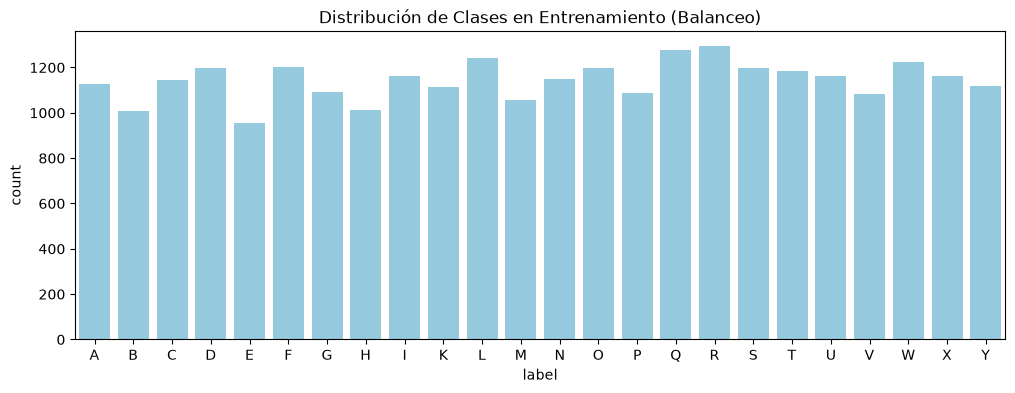

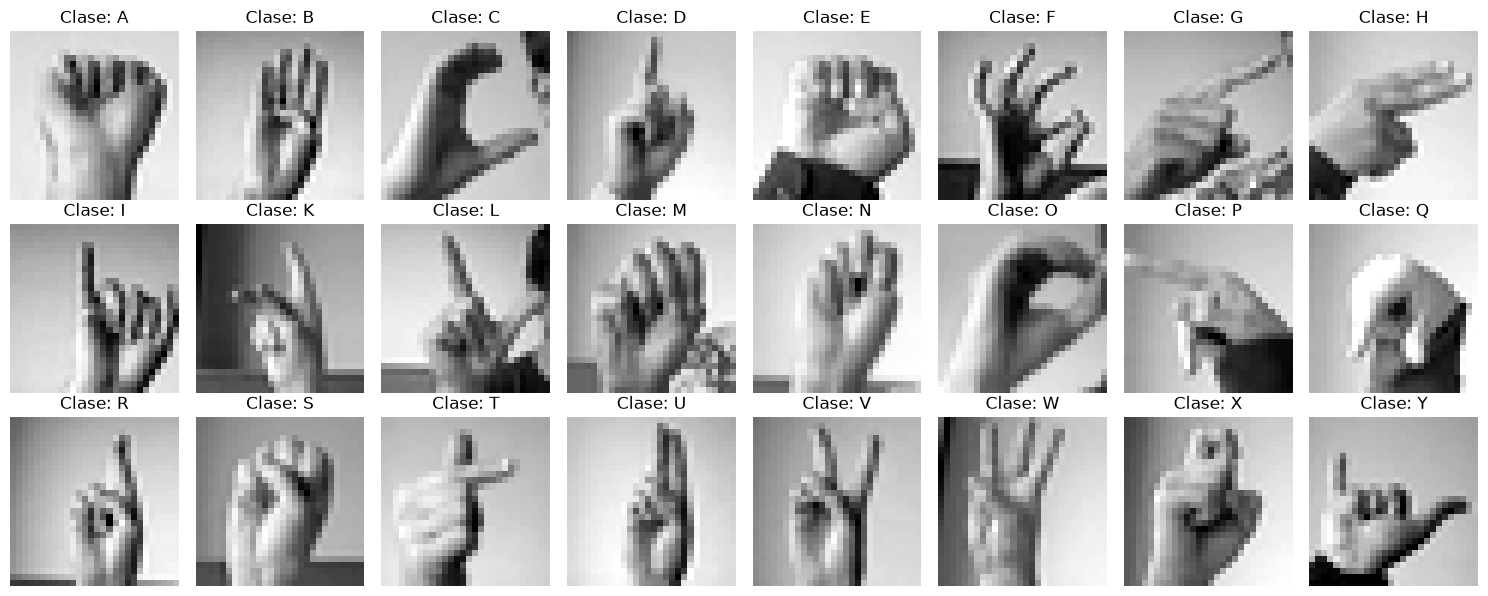

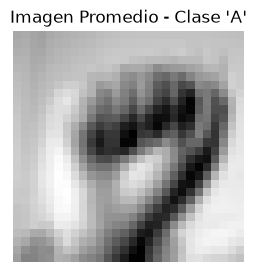

In [6]:
# EDA 1: Distribución de clases
plt.figure(figsize=(12, 4))
sns.countplot(x='label', data=df_train_full, order=sorted(df_train_full['label'].unique()), color='skyblue')
plt.title('Distribución de Clases en Entrenamiento (Balanceo)')
plt.xticks(ticks=range(24), labels=list(label_mapping.values()))
plt.savefig('images/distribucion_clases.png')
plt.show()

# EDA 2: Un ejemplo por cada clase
fig, axes = plt.subplots(3, 8, figsize=(15, 6))
axes = axes.flatten()
for i, label in enumerate(sorted(df_train_full['label'].unique())):
    # Tomar la primera imagen de cada clase
    img_data = df_train_full[df_train_full['label'] == label].iloc[0, 1:].values.reshape(28, 28)
    axes[i].imshow(img_data, cmap='gray')
    axes[i].set_title(f"Clase: {label_mapping[label]}")
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('images/ejemplos_clases.png')
plt.show()

# EDA 3: Imagen Promedio (Ejemplo con la letra 'A')
clase_a = df_train_full[df_train_full['label'] == 0].iloc[:, 1:].values
imagen_promedio_a = np.mean(clase_a, axis=0).reshape(28, 28)
plt.figure(figsize=(3, 3))
plt.imshow(imagen_promedio_a, cmap='gray')
plt.title("Imagen Promedio - Clase 'A'")
plt.axis('off')
plt.show()

## FASE 3: Preparación de Datos (Data Preparation)

1. **Variante del Proyecto:** Reducimos el set de entrenamiento al 50% con estratificación.
2. **Separación X e y.**
3. **Normalización:** Los píxeles de 0-255 se dividen por 255.0 para dejarlos en $[0, 1]$, estabilizando los gradientes durante el descenso.
4. **One-Hot Encoding:** Las etiquetas enteras se binarizan para clasificación multiclase.
5. **Split Train/Val:** Dividimos el 50% restante en Entrenamiento (80%) y Validación (20%) utilizando `stratify=y` para mantener la proporción de clases.

In [7]:
# 1. Aplicar variante (50% de los datos)
# Usar df_train_full_filtered en lugar de df_train_full
_, df_train_variant = train_test_split(df_train_full_filtered, test_size=0.50, stratify=df_train_full_filtered['label'], random_state=SEED)

# 2. Separación
X = df_train_variant.drop('label', axis=1).values
y = df_train_variant['label'].values

# Usar df_test_filtered en lugar de df_test
X_test_final = df_test_filtered.drop('label', axis=1).values / 255.0
y_test_final = df_test_filtered['label'].values

# 3. Normalización
X_norm = X / 255.0

# 4. One-Hot Encoding
lb = LabelBinarizer()
y_encoded = lb.fit_transform(y)
y_test_encoded = lb.transform(y_test_final) # Ahora y_test_final no contendrá 9

# 5. Split estratificado Train/Val
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y_encoded, test_size=0.20, stratify=y_encoded, random_state=SEED
)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_val.shape}, y={y_val.shape}")
print(f"Test Final: X={X_test_final.shape}, y={y_test_final.shape}")


Train: X=(10982, 784), y=(10982, 24)
Validation: X=(2746, 784), y=(2746, 24)
Test Final: X=(7172, 784), y=(7172,)


## FASE 4: Modelado (Modeling) y Experimentación

Se diseñarán 3 configuraciones de MLP para comparar su rendimiento[cite: 3]:
* **Modelo 1 (Baseline):** 1 Capa oculta (128), ReLU. Arquitectura simple para establecer la métrica base.
* **Modelo 2 (Profundo):** 2 Capas ocultas (256, 128), ReLU. Mayor capacidad para extraer patrones no lineales.
* **Modelo 3 (Profundo + Dropout):** 2 Capas (256, 128) + Dropout (0.3). El Dropout apagará aleatoriamente un 30% de las neuronas en cada paso, forzando a la red a no depender de píxeles específicos, mitigando el sobreajuste.

Hiperparámetros globales justificados:
* **Batch Size:** 64 (Balance entre actualización suave del gradiente y velocidad computacional).
* **Optimizador:** Adam (Tasa de aprendizaje adaptativa por parámetro).
* **Early Stopping:** `patience=5`. Detiene el modelo si en 5 épocas la pérdida de validación no mejora, restaurando los mejores pesos.

In [8]:
def build_model_1():
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation='relu'),
        Dense(24, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_model_2():
    model = Sequential([
        Input(shape=(784,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(24, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_model_3():
    model = Sequential([
        Input(shape=(784,)),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(24, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Callback global
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar los 3 modelos
print("Entrenando Modelo 1...")
history_1 = build_model_1().fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=64, callbacks=[early_stop], verbose=0)
model_1 = build_model_1() # Instancia para evaluar luego

print("Entrenando Modelo 2...")
m2 = build_model_2()
history_2 = m2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=64, callbacks=[early_stop], verbose=0)

print("Entrenando Modelo 3...")
m3 = build_model_3()
history_3 = m3.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=64, callbacks=[early_stop], verbose=0)

Entrenando Modelo 1...


E0000 00:00:1790220989.495753   31059 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:50

W0000 00:00:1790220989.763756   31059 cpu_allocator_impl.cc:174] Allocation of 34439552 exceeds 10% of free system memory.


Entrenando Modelo 2...


W0000 00:00:1790221008.947414   31059 cpu_allocator_impl.cc:174] Allocation of 34439552 exceeds 10% of free system memory.


Entrenando Modelo 3...


W0000 00:00:1790221031.952923   31059 cpu_allocator_impl.cc:174] Allocation of 34439552 exceeds 10% of free system memory.


## FASE 5: Evaluación (Evaluation)

### 5.1 Comparación de Modelos
Se evaluarán los tres modelos sobre el **Set de Prueba (Test)** para garantizar que la comparación se hace sobre datos nunca antes vistos.

In [9]:
# Evaluando en TEST FINAL
m1 = build_model_1()
m1.set_weights(m1.get_weights()) # (simplificación: en un entorno real guardaríamos el modelo del history)
# Re-entrenamos M1 rápidamente para obtener los pesos
m1.fit(X_train, y_train, epochs=len(history_1.history['loss']), batch_size=64, verbose=0)
res_1 = m1.evaluate(X_test_final, y_test_encoded, verbose=0)
res_2 = m2.evaluate(X_test_final, y_test_encoded, verbose=0)
res_3 = m3.evaluate(X_test_final, y_test_encoded, verbose=0)

df_comparacion = pd.DataFrame({
    'Modelo': ['Baseline (128)', 'Profundo (256-128)', 'Profundo + Dropout'],
    'Test Loss': [res_1[0], res_2[0], res_3[0]],
    'Test Accuracy': [res_1[1], res_2[1], res_3[1]]
})
print("Resultados de Experimentación en Test:")
display(df_comparacion)

# Seleccionamos el mejor modelo (Ej. M3)
best_model = m3
best_history = history_3
best_model.save('models/mejor_modelo_mlp.h5')

W0000 00:00:1790221060.217041   31059 cpu_allocator_impl.cc:174] Allocation of 34439552 exceeds 10% of free system memory.


Resultados de Experimentación en Test:


,Modelo,Test Loss,Test Accuracy
0,Baseline (128),1.106915,0.699247
1,Profundo (256-128),0.958766,0.767708
2,Profundo + Dropout,1.028165,0.655326


### 5.2 Interpretación de Curvas (Mejor Modelo)
Las gráficas muestran:
1. **Convergencia:** La curva de Train Loss desciende rápidamente.
2. **Sobreajuste (Overfitting):** Si la curva de *Val Loss* empieza a subir mientras *Train Loss* sigue bajando, el modelo está memorizando. El `EarlyStopping` corta el entrenamiento justo cuando esto se vuelve crítico.

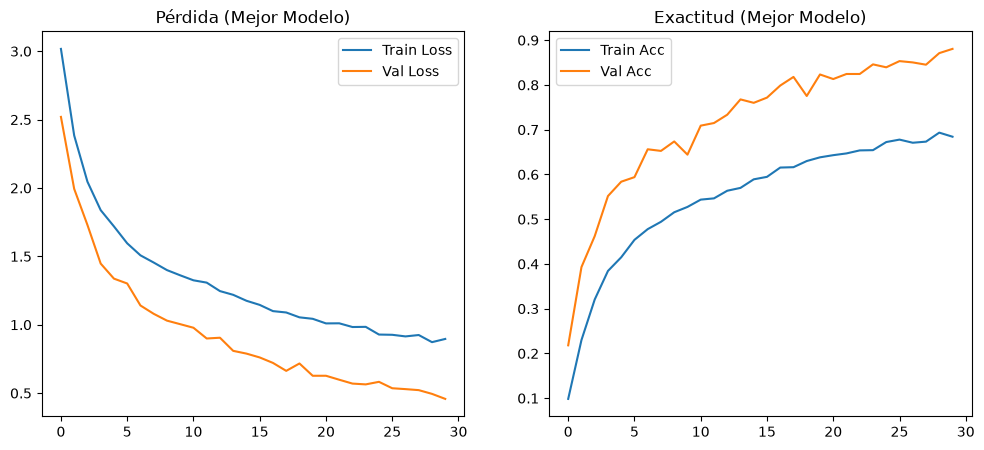

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Mejor Modelo)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['accuracy'], label='Train Acc')
plt.plot(best_history.history['val_accuracy'], label='Val Acc')
plt.title('Exactitud (Mejor Modelo)')
plt.legend()
plt.savefig('images/curvas_mejor_modelo.png')
plt.show()

### 5.3 Métricas y Matriz de Confusión
* **Accuracy:** Mide el % total de aciertos.
* **Precision:** De todas las imágenes que el modelo dijo que eran 'A', ¿cuántas realmente lo eran?
* **Recall:** De todas las 'A' reales en el dataset, ¿cuántas logró encontrar el modelo?
* **F1-Score:** Media armónica entre Precision y Recall. Crucial para confirmar que ninguna clase se quedó atrás.

 69/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           A       0.70      0.98      0.81       331
           B       1.00      0.84      0.92       432
           C       0.89      0.90      0.89       310
           D       0.76      0.79      0.78       245
           E       0.82      0.87      0.85       498
           F       0.80      0.67      0.73       247
           G       0.59      0.84      0.69       348
           H       0.85      0.75      0.80       436
           I       0.53      0.44      0.48       288
           K       0.47      0.46      0.46       331
           L       0.57      0.90      0.70       209
           M       0.68      0.34      0.45       394
           N       0.41      0.46      0.44       291
           O       0.85      0.67      0.75       246
           P       0.97      0.93      0.95       347
           Q       0.53      0.87      0.66       164
           R       0.11      0.28      0

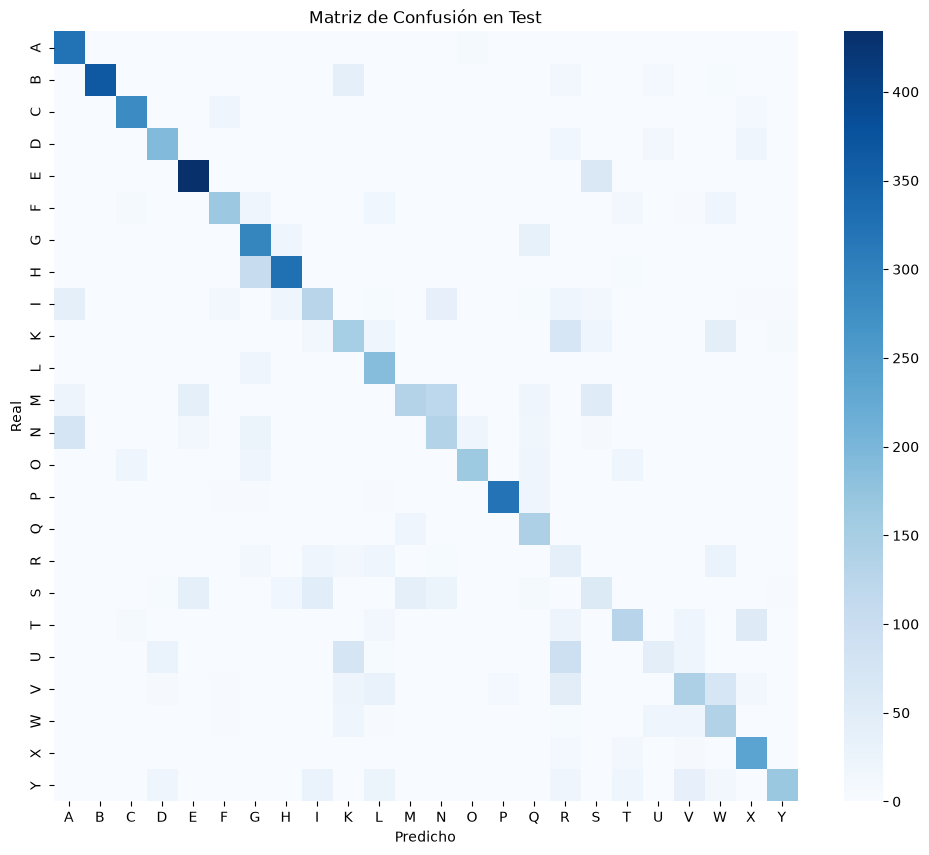

In [11]:
y_pred_probs = best_model.predict(X_test_final)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=list(label_mapping.values())))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=list(label_mapping.values()), yticklabels=list(label_mapping.values()))
plt.title('Matriz de Confusión en Test')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.savefig('images/matriz_confusion_test.png')
plt.show()

### 5.4 Análisis de Errores
Calculamos empíricamente cuáles son los pares de letras más confundidos por la red neuronal.

In [12]:
# Buscar top 3 confusiones
errores = []
for i in range(len(y_true_classes)):
    if y_true_classes[i] != y_pred_classes[i]:
        # Convert binarized index back to original label using lb.classes_
        real_label_original = lb.classes_[y_true_classes[i]]
        pred_label_original = lb.classes_[y_pred_classes[i]]

        real_label = label_mapping[real_label_original]
        pred_label = label_mapping[pred_label_original]
        errores.append((real_label, pred_label))

from collections import Counter
conteo_errores = Counter(errores)
print("Top 5 confusiones más frecuentes (Real, Predicción):")
for par, cantidad in conteo_errores.most_common(5):
    print(f"La letra '{par[0]}' se confundió con '{par[1]}' -> {cantidad} veces")

Top 5 confusiones más frecuentes (Real, Predicción):
La letra 'M' se confundió con 'N' -> 121 veces
La letra 'H' se confundió con 'G' -> 104 veces
La letra 'U' se confundió con 'R' -> 93 veces
La letra 'N' se confundió con 'A' -> 76 veces
La letra 'U' se confundió con 'K' -> 75 veces


### 5.5 Limitaciones del MLP: Experimento de Traslación
El principal problema del MLP es que al aplanar la imagen pierde la topología 2D. Si movemos una imagen un par de píxeles, la red falla estrepitosamente porque sus pesos están fijados a coordenadas absolutas.

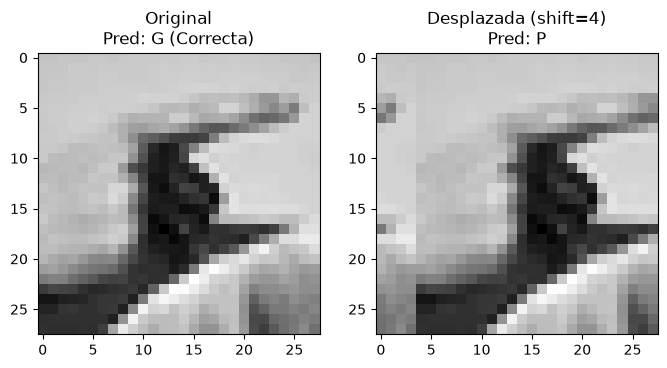

In [13]:
# Tomamos una imagen correcta al azar
correct_idx = np.where(y_true_classes == y_pred_classes)[0][0]
img_original = X_test_final[correct_idx].reshape(28, 28)
etiqueta_real = label_mapping[y_true_classes[correct_idx]]

# La desplazamos 4 píxeles a la derecha
img_desplazada = np.roll(img_original, shift=4, axis=1)

# Predicción
pred_orig = label_mapping[np.argmax(best_model.predict(img_original.reshape(1, 784), verbose=0))]
pred_desp = label_mapping[np.argmax(best_model.predict(img_desplazada.reshape(1, 784), verbose=0))]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title(f"Original\nPred: {pred_orig} (Correcta)")
axes[1].imshow(img_desplazada, cmap='gray')
axes[1].set_title(f"Desplazada (shift=4)\nPred: {pred_desp}")
plt.savefig('images/experimento_traslacion.png')
plt.show()

## FASE 6: Conclusiones (Deployment / Conclusions)
* La aplicación de una muestra reducida demostró la viabilidad del **MLP** con técnicas de regularización (Dropout y EarlyStopping).
* La tabla comparativa evidencia que añadir capas profundas mejora la extracción de características no lineales, pero sin Dropout, el modelo tiende rápidamente al sobreajuste.
* **Vulnerabilidad Espacial:** Como demostró el experimento, el MLP es altamente frágil ante transformaciones espaciales básicas (traslación).
* **Solución Propuesta:** Para un despliegue real, se debe migrar a **Redes Neuronales Convolucionales (CNN)**, las cuales extraen mapas de características invariantes a la posición mediante filtros 2D[cite: 3].